# Type 2 Diabetes Mellitus Prevalence, Risk Factors, and Trajectory 

### Libraries

In [25]:
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.ticker import MaxNLocator
import json
import numpy as np

In [2]:
df = pd.read_csv("../data/IHME-GBD_2023_DATA-e860792f-1/IHME-GBD_2023_DATA-e860792f-1.csv")

In [3]:
age_order = [
    "<5 years", "5-9 years", "10-14 years", "15-19 years",
    "20-24 years", "25-29 years", "30-34 years", "35-39 years",
    "40-44 years", "45-49 years", "50-54 years", "55-59 years",
    "60-64 years", "65-69 years", "70-74 years", "75-79 years",
    "80-84 years", "85-89 years", "90-94 years", "95+ years"
]

df["age_name"] = pd.Categorical(df["age_name"], categories=age_order, ordered=True)
df = df.sort_values("age_name")

In [4]:
df.head()

,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_id,age_name,cause_id,cause_name,metric_id,metric_name,year,val,upper,lower
0,5,Prevalence,36,Kazakhstan,3,Both,1,<5 years,976,Diabetes mellitus type 2,1,Number,2023,0.0,0.0,0.0
4769,5,Prevalence,163,India,3,Both,1,<5 years,976,Diabetes mellitus type 2,2,Percent,2023,0.0,0.0,0.0
4768,5,Prevalence,163,India,3,Both,1,<5 years,976,Diabetes mellitus type 2,1,Number,2023,0.0,0.0,0.0
4757,5,Prevalence,171,Democratic Republic of the Congo,3,Both,1,<5 years,976,Diabetes mellitus type 2,2,Percent,2023,0.0,0.0,0.0
4756,5,Prevalence,171,Democratic Republic of the Congo,3,Both,1,<5 years,976,Diabetes mellitus type 2,1,Number,2023,0.0,0.0,0.0


In [5]:
with open("../data/regions.json", "r", encoding="utf-8") as f:
    regions = json.load(f)
    
country_to_region = {
    country: region
    for region, countries in regions.items()
    for country in countries
}


In [6]:
df["region"] = [country_to_region[acountry] for acountry in df["location_name"].to_list()]

In [7]:
percent_df = df[df["metric_name"] == "Percent"]

In [8]:
percent_df.head()

,measure_id,measure_name,location_id,location_name,sex_id,sex_name,age_id,age_name,cause_id,cause_name,metric_id,metric_name,year,val,upper,lower,region
4769,5,Prevalence,163,India,3,Both,1,<5 years,976,Diabetes mellitus type 2,2,Percent,2023,0.0,0.0,0.0,South Asia
4757,5,Prevalence,171,Democratic Republic of the Congo,3,Both,1,<5 years,976,Diabetes mellitus type 2,2,Percent,2023,0.0,0.0,0.0,Central Sub-Saharan Africa
4739,5,Prevalence,162,Bhutan,3,Both,1,<5 years,976,Diabetes mellitus type 2,2,Percent,2023,0.0,0.0,0.0,South Asia
4725,5,Prevalence,160,Afghanistan,3,Both,1,<5 years,976,Diabetes mellitus type 2,2,Percent,2023,0.0,0.0,0.0,North Africa and Middle East
1593,5,Prevalence,74,Andorra,3,Both,1,<5 years,976,Diabetes mellitus type 2,2,Percent,2023,0.0,0.0,0.0,Western Europe


In [9]:
col_to_keep = ["region", "age_name", "val", "upper", "lower"]
percent_grouped_df = percent_df[col_to_keep].groupby(["region", "age_name"]).sum("val").reset_index()

/tmp/ipykernel_34593/2891395920.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  percent_grouped_df = percent_df[col_to_keep].groupby(["region", "age_name"]).sum("val").reset_index()


In [10]:
percent_grouped_df

,region,age_name,val,upper,lower
0,Andean Latin America,<5 years,0.000000,0.000000,0.000000
1,Andean Latin America,5-9 years,0.000000,0.000000,0.000000
2,Andean Latin America,10-14 years,0.000000,0.000000,0.000000
3,Andean Latin America,15-19 years,0.015922,0.020571,0.012122
4,Andean Latin America,20-24 years,0.027429,0.034107,0.022016
...,...,...,...,...,...
415,Western Sub-Saharan Africa,75-79 years,3.995975,4.476195,3.607470
416,Western Sub-Saharan Africa,80-84 years,3.736225,4.190660,3.360258
417,Western Sub-Saharan Africa,85-89 years,3.259732,3.682464,2.887376
418,Western Sub-Saharan Africa,90-94 years,2.637202,3.033483,2.281962


In [11]:
percent_grouped_df['region'].unique()

array(['Andean Latin America', 'Australasia', 'Caribbean', 'Central Asia',
       'Central Europe', 'Central Latin America',
       'Central Sub-Saharan Africa', 'East Asia', 'Eastern Europe',
       'Eastern Sub-Saharan Africa', 'High-income Asia Pacific',
       'High-income North America', 'North Africa and Middle East',
       'Oceania', 'South Asia', 'Southeast Asia',
       'Southern Latin America', 'Southern Sub-Saharan Africa',
       'Tropical Latin America', 'Western Europe',
       'Western Sub-Saharan Africa'], dtype=object)

In [12]:
percent_grouped_df['region'].unique()

array(['Andean Latin America', 'Australasia', 'Caribbean', 'Central Asia',
       'Central Europe', 'Central Latin America',
       'Central Sub-Saharan Africa', 'East Asia', 'Eastern Europe',
       'Eastern Sub-Saharan Africa', 'High-income Asia Pacific',
       'High-income North America', 'North Africa and Middle East',
       'Oceania', 'South Asia', 'Southeast Asia',
       'Southern Latin America', 'Southern Sub-Saharan Africa',
       'Tropical Latin America', 'Western Europe',
       'Western Sub-Saharan Africa'], dtype=object)

In [13]:

def age_midpoint(age):
    if age.startswith("<"):
        return 2.5
    if "+" in age:
        return 97.5
    start, end = age.split("-")
    return (int(start) + int(end.split()[0])) / 2

percent_grouped_df["age_mid"] = percent_grouped_df["age_name"].apply(age_midpoint)

In [36]:
range((nrows * ncols - ncols), nrows * ncols, 1)

range(18, 21)

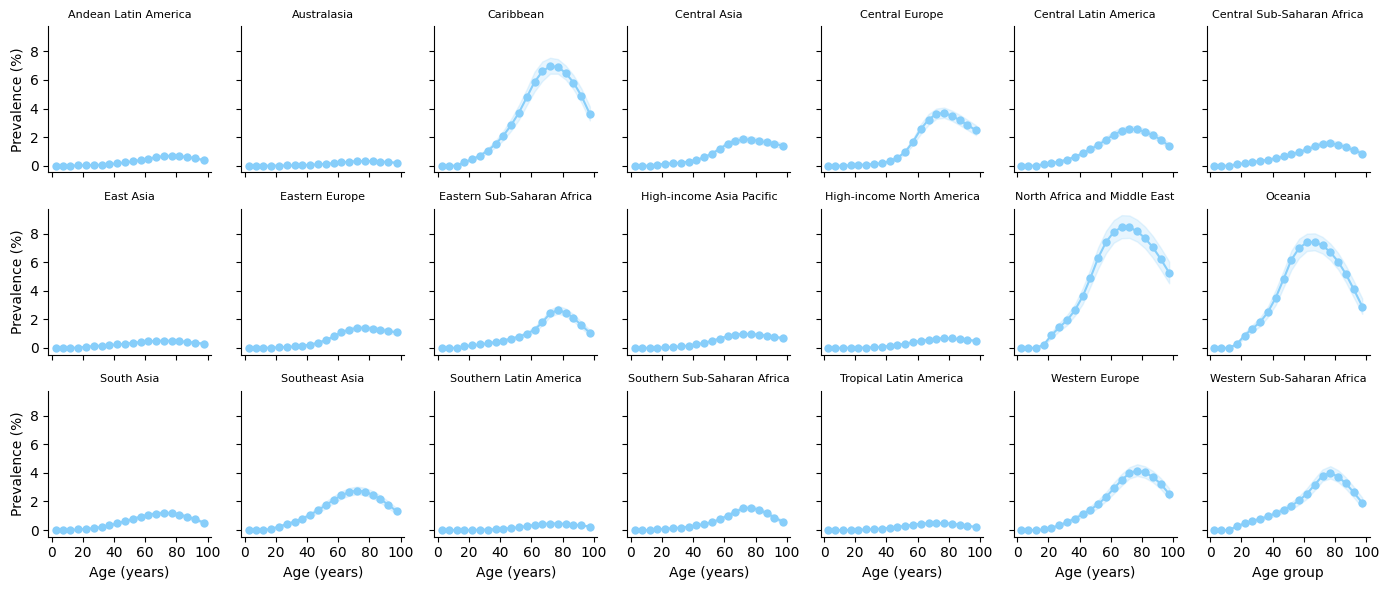

In [42]:
regions = percent_grouped_df['region'].unique()
n = len(regions)
nrows=3
ncols=7

label_xaxis = list(range((nrows * ncols - ncols), nrows * ncols))

fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(ncols*2, nrows*2), sharex=True, sharey=True)

axes = axes.flatten()

count = 0

for ax, region in zip(axes, regions):


    region_df = percent_grouped_df[percent_grouped_df['region'] == region]
    
    ax.plot(region_df['age_mid'], region_df['val'], label='Mean', marker='o', markeredgewidth=0, color="lightskyblue")
    ax.fill_between(
        region_df['age_mid'],
        region_df['lower'],
        region_df['upper'],
        color='lightskyblue', alpha=0.2
    )


    col = count % ncols
    if col == 0:
        ax.set_ylabel("Prevalence (%)")
    else:
        ax.set_ylabel("")
        ax.tick_params(axis="y", labelleft=False)


    if count in label_xaxis:
        ax.set_xlabel("Age (years)")
    else:
        ax.set_xlabel("")
        ax.tick_params(axis="x", labelleft=False)
    count += 1
    

    ax.xaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
    ax.set_title(region, fontsize=8)
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


plt.xlabel("Age group")
plt.tight_layout()
plt.show()

In [21]:
20 % 3

2